In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
train_path = r"F:\work\python\archive\classification_task\train"
test_path  = r"F:\work\python\archive\classification_task\test"

In [3]:
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4002 images belonging to 4 classes.
Found 998 images belonging to 4 classes.
Found 1000 images belonging to 4 classes.


In [4]:
def channel_attention(x, ratio=8):
    channels = x.shape[-1]

    avg_pool = GlobalAveragePooling2D()(x)
    avg_pool = Dense(channels//ratio, activation='relu')(avg_pool)
    avg_pool = Dense(channels, activation='sigmoid')(avg_pool)
    avg_pool = Reshape((1,1,channels))(avg_pool)

    return Multiply()([x, avg_pool])

In [5]:
def build_baseline():
    base = ResNet50(weights='imagenet',
                    include_top=False,
                    input_shape=(224,224,3))

    for layer in base.layers[:-40]:
        layer.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    out = Dense(4, activation='softmax')(x)

    return Model(base.input, out)

In [6]:
def build_channel():
    base = ResNet50(weights='imagenet',
                    include_top=False,
                    input_shape=(224,224,3))

    for layer in base.layers[:-40]:
        layer.trainable = False

    x = base.output
    x = channel_attention(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    out = Dense(4, activation='softmax')(x)

    return Model(base.input, out)

In [6]:
def train_and_evaluate(model, name):

    model.compile(
        optimizer=Adam(learning_rate=3e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    early = EarlyStopping(monitor='val_loss',
                          patience=5,
                          restore_best_weights=True)

    model.fit(train_gen,
              validation_data=val_gen,
              epochs=5,
              callbacks=[early])

    loss, acc = model.evaluate(test_gen)
    print(f"\n{name} Test Accuracy: {acc*100:.2f}%")

    test_gen.reset()
    preds = model.predict(test_gen)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

In [7]:
baseline = build_baseline()
train_and_evaluate(baseline, "Resnet50")

Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.6982 - loss: 0.7405 - val_accuracy: 0.3236 - val_loss: 1.3385
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.7719 - loss: 0.5510 - val_accuracy: 0.5892 - val_loss: 1.1207
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.8046 - loss: 0.4842 - val_accuracy: 0.6864 - val_loss: 0.9261
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.8198 - loss: 0.4590 - val_accuracy: 0.7104 - val_loss: 0.8000
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 340s 3s/step - accuracy: 0.8443 - loss: 0.4088 - val_accuracy: 0.7766 - val_loss: 0.8129
32/32 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.7110 - loss: 0.7948

Resnet50 Test Accuracy: 71.10%
32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 955ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.66      0.68       254
           1       0.59      0.66      0.62       306
           2       0.64  

In [11]:
channel_model = build_channel()
train_and_evaluate(channel_model, "Channel Attention")

Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.6987 - loss: 0.7705 - val_accuracy: 0.4469 - val_loss: 1.3056
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.7889 - loss: 0.5273 - val_accuracy: 0.7886 - val_loss: 0.8669
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - accuracy: 0.8121 - loss: 0.4784 - val_accuracy: 0.7886 - val_loss: 0.7631
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 258s 2s/step - accuracy: 0.8271 - loss: 0.4308 - val_accuracy: 0.7675 - val_loss: 0.7467
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.8498 - loss: 0.3902 - val_accuracy: 0.7926 - val_loss: 0.6376
32/32 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.7740 - loss: 0.6961

Channel Attention Test Accuracy: 77.40%
32/32 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.74      0.78       254
           1       0.74      0.51      0.61       306
           2       

In [13]:
def spatial_attention(x):
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=3, keepdims=True))(x)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=3, keepdims=True))(x)

    concat = Concatenate(axis=3)([avg_pool, max_pool])
    spatial = Conv2D(1, 7, padding='same', activation='sigmoid')(concat)

    return Multiply()([x, spatial])

In [15]:
def build_spatial():
    base = ResNet50(weights='imagenet',
                    include_top=False,
                    input_shape=(224,224,3))

    for layer in base.layers[:-40]:
        layer.trainable = False

    x = base.output
    x = spatial_attention(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    out = Dense(4, activation='softmax')(x)

    return Model(base.input, out)

In [17]:
spatial_model = build_spatial()
train_and_evaluate(spatial_model, "Spatial Attention")


Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.6764 - loss: 0.7849 - val_accuracy: 0.2786 - val_loss: 1.3724
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.7756 - loss: 0.5593 - val_accuracy: 0.7505 - val_loss: 0.8140
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.8013 - loss: 0.5028 - val_accuracy: 0.7114 - val_loss: 0.8595
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.8166 - loss: 0.4534 - val_accuracy: 0.7705 - val_loss: 0.8559
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 0.8403 - loss: 0.4003 - val_accuracy: 0.7405 - val_loss: 0.8969
32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 979ms/step - accuracy: 0.6920 - loss: 0.8367

Spatial Attention Test Accuracy: 69.20%
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 988ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.54      0.65       254
           1       0.59      0.45      0.51       306
           2

In [18]:
class SelfAttention(Layer):
    def __init__(self):
        super(SelfAttention, self).__init__()

    def build(self, input_shape):
        self.channels = input_shape[-1]
        self.query = Conv2D(self.channels//8, 1)
        self.key   = Conv2D(self.channels//8, 1)
        self.value = Conv2D(self.channels, 1)
        self.gamma = self.add_weight(shape=(1,),
                                     initializer="zeros",
                                     trainable=True)

    def call(self, x):
        batch_size = tf.shape(x)[0]
        h = x.shape[1]
        w = x.shape[2]
        c = self.channels

        query = self.query(x)
        key   = self.key(x)
        value = self.value(x)

        query = tf.reshape(query, [batch_size, -1, c//8])
        key   = tf.reshape(key, [batch_size, -1, c//8])
        value = tf.reshape(value, [batch_size, -1, c])

        attention = tf.matmul(query, key, transpose_b=True)
        attention = tf.nn.softmax(attention, axis=-1)

        out = tf.matmul(attention, value)
        out = tf.reshape(out, [batch_size, h, w, c])

        return self.gamma * out + x

In [19]:
def build_self():
    base = ResNet50(weights='imagenet',
                    include_top=False,
                    input_shape=(224,224,3))

    for layer in base.layers[:-40]:
        layer.trainable = False

    x = base.output
    x = SelfAttention()(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    out = Dense(4, activation='softmax')(x)

    return Model(base.input, out)

In [20]:
self_model = build_self()
train_and_evaluate(self_model, "Self Attention")

Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.7061 - loss: 0.7498 - val_accuracy: 0.2134 - val_loss: 1.4575
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.7834 - loss: 0.5521 - val_accuracy: 0.5952 - val_loss: 1.1053
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.7989 - loss: 0.4826 - val_accuracy: 0.7265 - val_loss: 0.8927
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.8343 - loss: 0.4270 - val_accuracy: 0.6774 - val_loss: 1.1423
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 376s 3s/step - accuracy: 0.8286 - loss: 0.4301 - val_accuracy: 0.7575 - val_loss: 0.7545
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 831ms/step - accuracy: 0.7640 - loss: 0.7333

Self Attention Test Accuracy: 76.40%
32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 910ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.85      0.77       254
           1       0.74      0.47      0.57       306
           2    

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def print_confusion_matrix(model, test_gen, model_name):

    # Get predictions
    test_gen.reset()
    preds = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    # Compute CM
    cm = confusion_matrix(y_true, y_pred)
    class_labels = list(test_gen.class_indices.keys())

    # Plot
    plt.figure(figsize=(6,6))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=class_labels,
                yticklabels=class_labels)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()

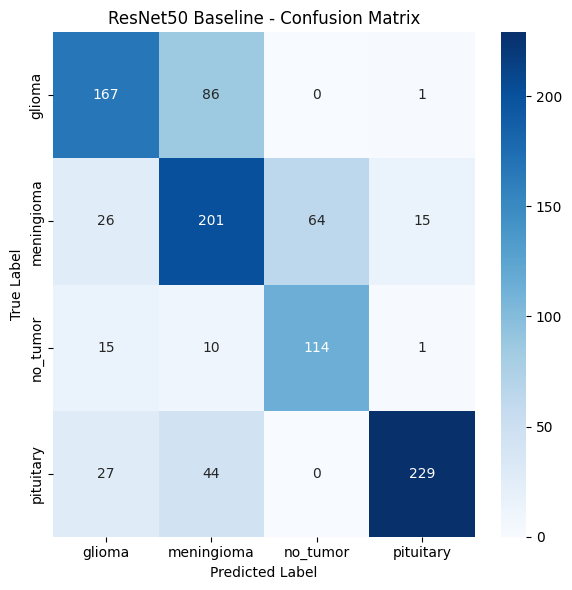

In [11]:
print_confusion_matrix(baseline, test_gen, "ResNet50 Baseline")

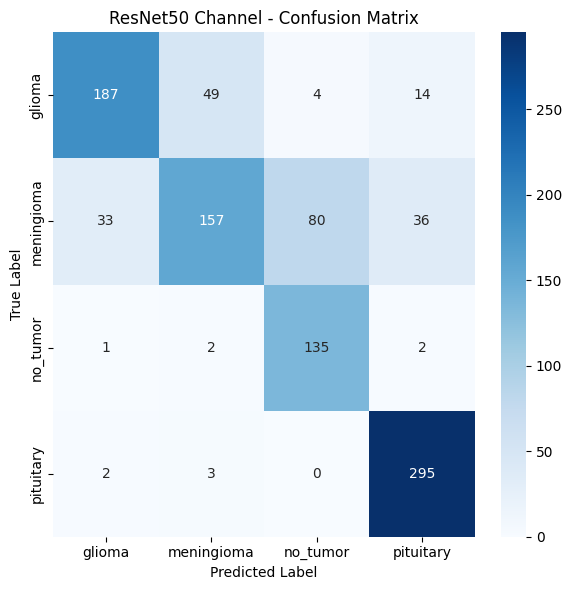

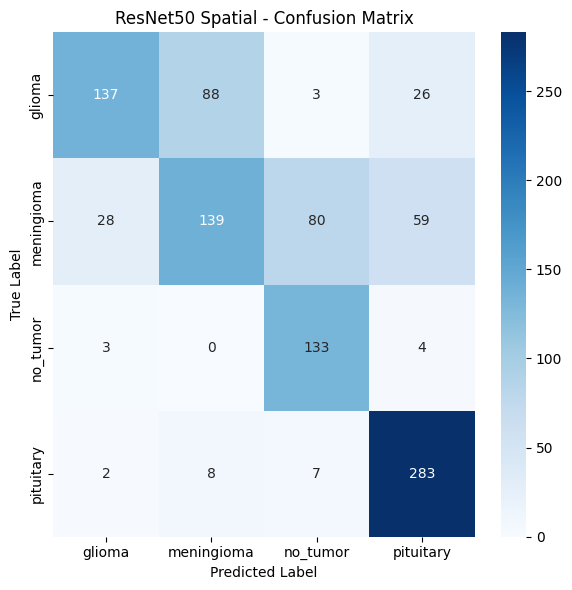

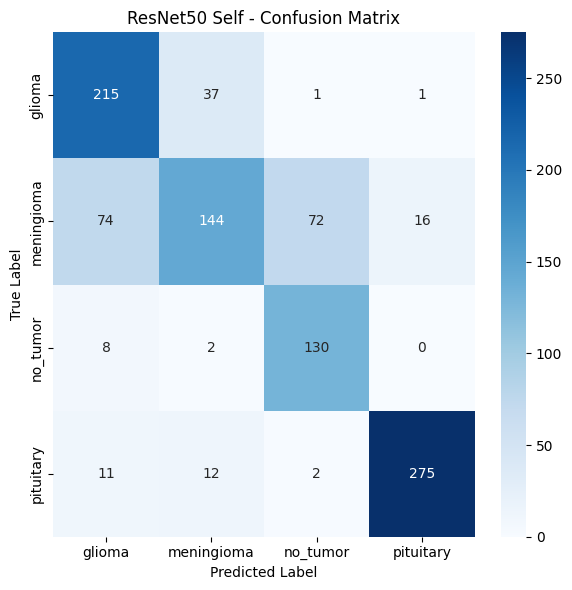

In [24]:
print_confusion_matrix(channel_model, test_gen, "ResNet50 Channel")
print_confusion_matrix(spatial_model, test_gen, "ResNet50 Spatial")
print_confusion_matrix(self_model, test_gen, "ResNet50 Self")